# **Analisis Sentimen dan Jaringan Sosial pada Media Sosial X untuk Menilai Persepsi Publik terhadap Program Stunting di Indonesia**

## Rumusan Masalah
Rumusan masalah yang menjadi fokus penelitian ini adalah sebagai berikut:

1. Bagaimana hasil sentimen publik terhadap program stunting 2024 di media sosial X menggunakan VADER Lexicon dan BERT?
2. Bagaimana perbandingan tingkat akurasi algoritma machine learning GBT, SVM, dan XGBoost dalam mengklasifikasikan sentimen publik terhadap program stunting?
3. Bagaimana posisi dan peran aktor dalam jaringan sosial yang terbentuk dari percakapan mengenai program stunting di media sosial X?

## 2. Import Library dan Data

In [9]:
!pip install nltk
!pip install Sastrawi
# !pip install gensim

In [2]:
# Core Libraries
import os # Interact with the operating system
import re # Regular expressions for text processing [https://regex101.com/]
import random # Random number generators and sequence shuffling
import string # Operations on strings, e.g., punctuation
import json

# Data Manipulation and Processing
import numpy as np # Linear algebra and numerical computations
import pandas as pd # Data processing, e.g., reading/writing CSV files and manipulating DataFrames
pd.set_option("display.max_columns", None) # Ensure all columns are displayed

# Visualization Libraries
import matplotlib.pyplot as plt # Plotting and data visualization
import seaborn as sns # Statistical data visualization
from plotly import graph_objs as go # Advanced interactive visualizations
import plotly.express as px # High-level API for Plotly visualizations
import plotly.figure_factory as ff # Additional Plotly visualization tools

# Natural Language Processing (NLP) Libraries
import nltk # Natural Language Toolkit for NLP tasks
from nltk.corpus import stopwords # List of stopwords for text preprocessing
from nltk.tokenize import word_tokenize # Tokenization of text into words
from nltk.stem import WordNetLemmatizer, PorterStemmer # Stemming and Lemmatization
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory # Indonesian language stemming

# Text Feature Extraction
from sklearn.feature_extraction.text import (
    TfidfTransformer, # Transform term frequency matrix to TF-IDF
    CountVectorizer, # Convert text into a bag-of-words representation
    TfidfVectorizer # Transform text into TF-IDF representation
)

# Machine Learning and Preprocessing
from sklearn.model_selection import train_test_split # Split data into train and test sets
from sklearn.preprocessing import StandardScaler, FunctionTransformer # Data scaling and transformation

# Evaluation Metrics for Machine Learning Models
from sklearn.metrics import (
    precision_score, # Ratio of true positives to total predicted positives
    recall_score, # Ratio of true positives to total actual positives
    f1_score, # Harmonic mean of precision and recall
    classification_report, # Summary of precision, recall, F1 score, and support
    accuracy_score # Proportion of correct predictions
)

# Miscellaneous Utilities
from tqdm import tqdm # Progress bar for monitoring loops and tasks
from collections import Counter # Count elements in a collection

# Word Clouds and Image Processing
from PIL import Image # Image processing library
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator # Generate and customize word clouds

# Gensim for Topic Modeling
# import gensim # Library for topic modeling and vector space modeling


In [10]:
nltk.download(['stopwords', 'punkt', 'wordnet'])
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
import pandas as pd

# Tentukan path folder yang berisi file CSV
folder_path = '/content/drive/MyDrive/Laporan_NLP/NLP/Data/'

# Membuat list untuk menyimpan DataFrame
dataframes = []

# Loop melalui semua file dalam folder
for file_name in os.listdir(folder_path):
    # Cek apakah file berformat .csv
    if file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        # Membaca file CSV dan menambahkannya ke list
        df = pd.read_csv(file_path)
        dataframes.append(df)

# Menggabungkan semua DataFrame
db_gab = pd.concat(dataframes, ignore_index=True)

# Pilih kolom yang diinginkan
db_merge = db_gab.copy()
db_merge = db_merge[["created_at", "location", "reply_count", "username", "full_text"]]

# Opsional: Mengecek dimensi hasil penggabungan
print(f"Dimensi hasil gabungan: {db_merge.shape}")

Dimensi hasil gabungan: (8527, 5)


In [6]:
db_gab.head(2)

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1827439300843295146,Fri Aug 30 23:58:53 +0000 2024,0,cuma yang nggak mengalami PTSD yang digunain b...,1829670154965565473,NaN,oravine_,in,NaN,0,1,0,https://x.com/oravine_/status/1829670154965565473,1355533155835338755,oravine_
1,1829668756404256791,Fri Aug 30 23:53:19 +0000 2024,0,Dinas Pekerjaan Umum dan Penataan Ruang (DPUPR...,1829668756404256791,https://pbs.twimg.com/media/GWRKCAoWYAEuN1q.jpg,NaN,in,NaN,0,0,0,https://x.com/sebayu_94FM/status/1829668756404...,1356472072378048512,sebayu_94FM


In [7]:
# # Menampilkan 5 baris pertama hasil gabungan
# db_merge.head()

,created_at,location,reply_count,username,full_text
0,Fri Aug 30 23:58:53 +0000 2024,NaN,1,oravine_,cuma yang nggak mengalami PTSD yang digunain b...
1,Fri Aug 30 23:53:19 +0000 2024,NaN,0,sebayu_94FM,Dinas Pekerjaan Umum dan Penataan Ruang (DPUPR...
2,Fri Aug 30 23:35:42 +0000 2024,bts.day6.iKON,0,raquellstep,@ajengrizkyJ @bibahjenner @tanyakanrl kak maaf...
3,Fri Aug 30 23:32:10 +0000 2024,NaN,1,ajengrizkyJ,@raquellstep @bibahjenner @tanyakanrl Belajar ...
4,Fri Aug 30 23:28:32 +0000 2024,"Denpasar, Bali",0,Kanwil_Bali,DUKUNG PENCEGAHAN STUNTING POSYANDU IBU DAN BA...


In [8]:
# db_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8527 entries, 0 to 8526
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   created_at   8527 non-null   object
 1   location     4725 non-null   object
 2   reply_count  8527 non-null   int64 
 3   username     8527 non-null   object
 4   full_text    8527 non-null   object
dtypes: int64(1), object(4)
memory usage: 333.2+ KB


## Data Preprocessing and Labeling

### 1.Remove Duplicates

Tujuan: Menghapus baris duplikat pada dataset untuk menghindari bias dalam analisis.

In [9]:
# # Menghitung jumlah duplikat sebelum penghapusan
# duplicates_before = db_merge.duplicated(subset=['full_text']).sum()
# print(f"Jumlah duplikat sebelum penghapusan: {duplicates_before}")

# # Menghapus duplikat
# db_merge = db_merge.drop_duplicates(subset=['full_text']).reset_index(drop=True)

# # Menghitung jumlah duplikat setelah penghapusan
# duplicates_after = db_merge.duplicated(subset=['full_text']).sum()
# print(f"Jumlah duplikat setelah penghapusan: {duplicates_after}")


Jumlah duplikat sebelum penghapusan: 456
Jumlah duplikat setelah penghapusan: 0


In [10]:
# db_merge.head()

,created_at,location,reply_count,username,full_text
0,Fri Aug 30 23:58:53 +0000 2024,NaN,1,oravine_,cuma yang nggak mengalami PTSD yang digunain b...
1,Fri Aug 30 23:53:19 +0000 2024,NaN,0,sebayu_94FM,Dinas Pekerjaan Umum dan Penataan Ruang (DPUPR...
2,Fri Aug 30 23:35:42 +0000 2024,bts.day6.iKON,0,raquellstep,@ajengrizkyJ @bibahjenner @tanyakanrl kak maaf...
3,Fri Aug 30 23:32:10 +0000 2024,NaN,1,ajengrizkyJ,@raquellstep @bibahjenner @tanyakanrl Belajar ...
4,Fri Aug 30 23:28:32 +0000 2024,"Denpasar, Bali",0,Kanwil_Bali,DUKUNG PENCEGAHAN STUNTING POSYANDU IBU DAN BA...


### 2.Text Cleaning Process

Tujuan: Membersihkan teks dari karakter yang tidak relevan seperti tag, URL, angka, dan tanda baca.

In [11]:
# import re
# import unicodedata

# def cleaning(content):
#     # Mengubah ke huruf kecil
#     content = content.lower()
#     # Menghapus karakter non-ASCII
#     content = unicodedata.normalize('NFKD', content).encode('ascii', 'ignore').decode('utf-8', 'ignore')
#     # Menghapus URL
#     content = re.sub(r'(?i)\b((?:https?://|www\d{0,3}[.]|[a-z0-9.\-]+[.][a-z]{2,4}/)(?:[^\s()<>]+|\(([^\s()<>]+|(\([^\s()<>]+\)))*\))+(?:\(([^\s()<>]+|(\([^\s()<>]+\)))*\)|[^\s`!()\[\]{};:\'".,<>?«»“”‘’]))', '', content)
#     # Menghapus tanda baca
#     content = re.sub(r'[^\w]|_',' ', content)
#     # Menghapus digit dari string
#     content = re.sub("\S*\d\S*", "", content).strip()
#     # Menghapus angka atau digit
#     content = re.sub(r"\b\d+\b", " ", content)
#     # Menghapus spasi tambahan
#     content = re.sub('[\s]+', ' ', content)
#     # Menghilangkan spasi awal/akhir
#     content = content.strip(' ')

#     return content

# # Terapkan fungsi ke kolom 'full_text' untuk membuat kolom 'Cleaned_Text'
# db_merge['Cleaned_Text'] = db_merge['full_text'].apply(cleaning)


In [12]:
# db_merge[['full_text', 'Cleaned_Text']].head()

,full_text,Cleaned_Text
0,cuma yang nggak mengalami PTSD yang digunain b...,cuma yang nggak mengalami ptsd yang digunain b...
1,Dinas Pekerjaan Umum dan Penataan Ruang (DPUPR...,dinas pekerjaan umum dan penataan ruang dpupr ...
2,@ajengrizkyJ @bibahjenner @tanyakanrl kak maaf...,ajengrizkyj bibahjenner tanyakanrl kak maaf bg...
3,@raquellstep @bibahjenner @tanyakanrl Belajar ...,raquellstep bibahjenner tanyakanrl belajar yg ...
4,DUKUNG PENCEGAHAN STUNTING POSYANDU IBU DAN BA...,dukung pencegahan stunting posyandu ibu dan ba...


### 3.Tokenizing

In [13]:
# def tokenize_content(content):
#     return word_tokenize(content)

# # Tokenisasi sebelum formalisasi
# db_merge['Tokenized_Text'] = db_merge['Cleaned_Text'].apply(word_tokenize)

In [14]:
# db_merge.head()

,created_at,location,reply_count,username,full_text,Cleaned_Text,Tokenized_Text
0,Fri Aug 30 23:58:53 +0000 2024,NaN,1,oravine_,cuma yang nggak mengalami PTSD yang digunain b...,cuma yang nggak mengalami ptsd yang digunain b...,"[cuma, yang, nggak, mengalami, ptsd, yang, dig..."
1,Fri Aug 30 23:53:19 +0000 2024,NaN,0,sebayu_94FM,Dinas Pekerjaan Umum dan Penataan Ruang (DPUPR...,dinas pekerjaan umum dan penataan ruang dpupr ...,"[dinas, pekerjaan, umum, dan, penataan, ruang,..."
2,Fri Aug 30 23:35:42 +0000 2024,bts.day6.iKON,0,raquellstep,@ajengrizkyJ @bibahjenner @tanyakanrl kak maaf...,ajengrizkyj bibahjenner tanyakanrl kak maaf bg...,"[ajengrizkyj, bibahjenner, tanyakanrl, kak, ma..."
3,Fri Aug 30 23:32:10 +0000 2024,NaN,1,ajengrizkyJ,@raquellstep @bibahjenner @tanyakanrl Belajar ...,raquellstep bibahjenner tanyakanrl belajar yg ...,"[raquellstep, bibahjenner, tanyakanrl, belajar..."
4,Fri Aug 30 23:28:32 +0000 2024,"Denpasar, Bali",0,Kanwil_Bali,DUKUNG PENCEGAHAN STUNTING POSYANDU IBU DAN BA...,dukung pencegahan stunting posyandu ibu dan ba...,"[dukung, pencegahan, stunting, posyandu, ibu, ..."


### 4.Formulasi atau Slang Word Normalization

Tahap formalisasi dilakukan untuk pengubah penggunaan kata tidak baku menjadi baku sesuai dengan KBBI. Proses akan menggunakan file dataset slangwords yang berisi kata slang yang nanti akan diubah menjadi baku. Tahap ini dibantu dengan library RegEx.

In [15]:

# # Fungsi untuk memuat dan mengonversi kata-kata slang menjadi kata baku
# def convertToSlangword(ulasan):
#     # Menyertakan path yang benar untuk file slang words
#     slang_file_path = "/content/drive/MyDrive/Laporan_NLP/NLP/combined_slang_words.txt"

#     # Membaca file JSON yang berisi kamus slang
#     with open(slang_file_path, "r") as file:
#         kamusSlang = json.load(file)

#     # Membuat pola RegEx untuk mendeteksi kata slang di dalam teks
#     pattern = re.compile(r'\b(' + '|'.join(kamusSlang.keys()) + r')\b')

#     # Ubah setiap kata slang yang ditemukan dalam ulasan menjadi kata baku
#     content = []
#     for kata in ulasan:
#         filterSlang = pattern.sub(lambda x: kamusSlang[x.group()], kata)
#         content.append(filterSlang.lower())

#     return content

# # Terapkan formalisasi
# db_merge['Formalized_Text'] = db_merge['Tokenized_Text'].apply(convertToSlangword)

In [16]:
db_merge.head()

,created_at,location,reply_count,username,full_text,Cleaned_Text,Tokenized_Text,Formalized_Text
0,Fri Aug 30 23:58:53 +0000 2024,NaN,1,oravine_,cuma yang nggak mengalami PTSD yang digunain b...,cuma yang nggak mengalami ptsd yang digunain b...,"[cuma, yang, nggak, mengalami, ptsd, yang, dig...","[cuma, yang, tidak, mengalami, ptsd, yang, dig..."
1,Fri Aug 30 23:53:19 +0000 2024,NaN,0,sebayu_94FM,Dinas Pekerjaan Umum dan Penataan Ruang (DPUPR...,dinas pekerjaan umum dan penataan ruang dpupr ...,"[dinas, pekerjaan, umum, dan, penataan, ruang,...","[dinas, pekerjaan, umum, dan, penataan, ruang,..."
2,Fri Aug 30 23:35:42 +0000 2024,bts.day6.iKON,0,raquellstep,@ajengrizkyJ @bibahjenner @tanyakanrl kak maaf...,ajengrizkyj bibahjenner tanyakanrl kak maaf bg...,"[ajengrizkyj, bibahjenner, tanyakanrl, kak, ma...","[ajengrizkyj, bibahjenner, tanyakanrl, kak, ma..."
3,Fri Aug 30 23:32:10 +0000 2024,NaN,1,ajengrizkyJ,@raquellstep @bibahjenner @tanyakanrl Belajar ...,raquellstep bibahjenner tanyakanrl belajar yg ...,"[raquellstep, bibahjenner, tanyakanrl, belajar...","[raquellstep, bibahjenner, tanyakanrl, belajar..."
4,Fri Aug 30 23:28:32 +0000 2024,"Denpasar, Bali",0,Kanwil_Bali,DUKUNG PENCEGAHAN STUNTING POSYANDU IBU DAN BA...,dukung pencegahan stunting posyandu ibu dan ba...,"[dukung, pencegahan, stunting, posyandu, ibu, ...","[dukung, pencegahan, stunting, posyandu, ibu, ..."


### 6.Stopword Removal
Tujuan: Menghapus kata-kata umum yang tidak memiliki makna penting (stopwords).

In [17]:
# import pandas as pd
# from nltk.corpus import stopwords
# from nltk.tokenize import word_tokenize

In [18]:
# # Daftar stopwords bahasa Indonesia dengan tambahan kata-kata spesifik
# stop_words = stopwords.words('indonesian')
# stop_words.extend([
#     "yang", "yg", "dg", "rt", "dgn", "ny", "d", "ga", "klo", "kalo", "amp", "biar",
#     "bikin", "bilang", "gak", "g", "krn", "nya", "sih", "si", "tau", "tdk",
#     "utk", "ya", "jd", "jgn", "sdh", "aja", "n", "t", "nyg", "hehe", "pen",
#     "u", "loh", "yah", "gmn", "ttp", "dk", "kn", "dlm", "kl", "b", "dan",
#     "yang", "di", "dengan", "dari", "kamu", "jadi", "ke", "itu", "ini",
#     "saja", "juga", "lagi", "ada", "untuk", "eh", "lho", "makanya", "biang",
#     "asik", "maksudnya", "apakah", "bagaimana", "seperti", "gitu", "oh",
#     "aku", "lo", "tuh", "pasti", "kalau", "sama", "kapan", "mereka", "kalian",
#     "cuma", "selalu", "yuk", "nah", "misalnya", "gimana", "soalnya", "bisa",
#     "pengen", "coba", "eh", "yaudah", "sih", "gitu", "serius", "pasti", "belum",
#     "menurut", "tau", "tuh", "loh", "sudah", "gak", "cuma", "udah", "mungkin",
#     "ayo", "apalagi", "tapi", "jadi", "nggak", "ngomong", "gitu", "itu",
#     "emang", "kenapa", "iya", "juga", "pasti", "pernah", "dulu", "kebanyakan",
#     "sekarang", "dong", "bener", "kalo", "lalu", "begitu", "sama", "aja", "terus",
#     "kesini", "langsung", "lah", "buat", "mengapa", "lebih", "lebih baik", "kan",
#     "katanya", "nggak", "bilang", "anggap", "kalau", "apa", "bagi", "deh",
#     "dalam", "bagian", "kita", "ini", "untuk", "senang", "mengatakan", "semua",
#     "gitu", "lah", "nah", "kami", "aja", "ah", "ak", "ambilin", "ap2", "apaan",
#     "apesh", "baiklah", "basah", "bdg", "beberapa", "beliin", "beut", "biasa",
#     "bicara", "biologi", "bgs", "biang", "buru", "bawa", "bolak", "bolos", "bubur",
#     "cadangan", "ceper", "ciluk", "clol", "cok", "curhat", "dan", "deh", "depan",
#     "dll", "dong", "dulu", "dikirim", "dlm", "ga", "gak", "gak banget", "gak ya",
#     "gemes", "gokil", "gues", "gini", "gitu", "gg", "goblok", "gue", "haduh", "hati-hati",
#     "heeh", "harus", "hati", "hidup", "hilang", "honor", "huh", "itu", "jangan", "jelek",
#     "jadi", "juga", "jgn", "ka", "kabur", "kami", "kampret", "kan", "kapan", "kata",
#     "kebanyakan", "kebanyakan", "kemana", "kemaren", "kemerdekaan", "kenapa", "kecuali",
#     "keluar", "kl", "kk", "komputer", "koq", "kya", "lebih", "lalu", "lama", "lagi",
#     "lapor", "lebaran", "langsung", "lah", "layak", "lewat", "main", "makanan", "makasih",
#     "malaikat", "maksudnya", "makan", "mampir", "manusia", "mau", "misalnya",
#     "mood", "ngabers", "ngelamun", "ngga", "ngomongin", "ngomongnya", "ngomong",
#     "no", "oke", "otw", "pake", "pas", "pasti", "penjelasan", "pengetahuan", "pesan",
#     "pulang", "ragu", "ringan", "saja", "salam", "sakit", "sekarang", "seperti", "semua",
#     "sering", "semua", "semuanya", "seperti", "sial", "simpan", "simpel", "tidak", "tiko",
#     "tolo", "tuh", "udah", "up", "wah", "ya", "yaudah", "yg", "ygs", "yg",
#     "yuk", "zz", "sinyal"
#     ])

# def removeStopword(text):
#     # Pastikan text adalah string
#     if not isinstance(text, str):  # Jika bukan string, konversi ke string
#         text = str(text)

#     # Tokenisasi kata
#     word_tokens = word_tokenize(text)

#     # Filter stopwords
#     filtered_sentence = [w for w in word_tokens if w.lower() not in stop_words]
#     return ' '.join(filtered_sentence)

# # Terapkan fungsi ke kolom 'Formalized_Text' untuk membuat kolom 'Stopword_Removed_Text'
# db_merge['Stopword_Removed_Text'] = db_merge['Formalized_Text'].apply(lambda x: removeStopword(x))



In [19]:
# db_merge[['Formalized_Text', 'Stopword_Removed_Text']].head()

,Formalized_Text,Stopword_Removed_Text
0,"[cuma, yang, tidak, mengalami, ptsd, yang, dig...","[ 'cuma ' , 'yang ' , 'tidak ' , 'mengalami ' ..."
1,"[dinas, pekerjaan, umum, dan, penataan, ruang,...","[ 'dinas ' , 'pekerjaan ' , 'umum ' , 'dan ' ,..."
2,"[ajengrizkyj, bibahjenner, tanyakanrl, kak, ma...","[ 'ajengrizkyj ' , 'bibahjenner ' , 'tanyakanr..."
3,"[raquellstep, bibahjenner, tanyakanrl, belajar...","[ 'raquellstep ' , 'bibahjenner ' , 'tanyakanr..."
4,"[dukung, pencegahan, stunting, posyandu, ibu, ...","[ 'dukung ' , 'pencegahan ' , 'stunting ' , 'p..."


### 7.Stemming
Tujuan: Mengubah kata menjadi bentuk dasar. Stemming menggunakan Sastrawi.

In [20]:
# from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# # Inisialisasi Stemmer (Sastrawi)
# factory = StemmerFactory()
# stemmer = factory.create_stemmer()

# # Fungsi Stemming
# def stemmingText(text):
#     words = text.split()
#     stemmed_words = [stemmer.stem(word) for word in words]
#     return ' '.join(stemmed_words)  # Gabungkan kembali menjadi kalimat

# # Terapkan stemming pada teks yang sudah dibersihkan dari stopword
# db_merge['Stemmed_Text'] = db_merge['Stopword_Removed_Text'].apply(lambda x: stemmingText(x) if isinstance(x, str) else "")
# # Lakukan tokenisasi setelah stemming
# db_merge['Stemmed_Text'] = db_merge['Stemmed_Text'].apply(lambda x: word_tokenize(x) if isinstance(x, str) else [])
# # Tampilkan beberapa baris contoh
# db_merge[['Formalized_Text', 'Stopword_Removed_Text', 'Stemmed_Text']].head()


,Formalized_Text,Stopword_Removed_Text,Stemmed_Text
0,"[cuma, yang, tidak, mengalami, ptsd, yang, dig...","[ 'cuma ' , 'yang ' , 'tidak ' , 'mengalami ' ...","[cuma, yang, tidak, alami, ptsd, yang, digunai..."
1,"[dinas, pekerjaan, umum, dan, penataan, ruang,...","[ 'dinas ' , 'pekerjaan ' , 'umum ' , 'dan ' ,...","[dinas, kerja, umum, dan, tata, ruang, dpupr, ..."
2,"[ajengrizkyj, bibahjenner, tanyakanrl, kak, ma...","[ 'ajengrizkyj ' , 'bibahjenner ' , 'tanyakanr...","[ajengrizkyj, bibahjenner, tanyakanrl, kak, ma..."
3,"[raquellstep, bibahjenner, tanyakanrl, belajar...","[ 'raquellstep ' , 'bibahjenner ' , 'tanyakanr...","[raquellstep, bibahjenner, tanyakanrl, ajar, y..."
4,"[dukung, pencegahan, stunting, posyandu, ibu, ...","[ 'dukung ' , 'pencegahan ' , 'stunting ' , 'p...","[dukung, cegah, stunting, posyandu, ibu, dan, ..."


### 8.Cek Data Duplikat kembali

In [21]:
# # Menghitung jumlah duplikat sebelum penghapusan
# duplicates_before = db_merge.duplicated(subset=['Stemmed_Text']).sum()
# print(f"Jumlah duplikat sebelum penghapusan: {duplicates_before}")

# # Menghapus duplikat
# db_merge = db_merge.drop_duplicates(subset=['Stemmed_Text']).reset_index(drop=True)

# # Menghitung jumlah duplikat setelah penghapusan
# duplicates_after = db_merge.duplicated(subset=['Stemmed_Text']).sum()
# print(f"Jumlah duplikat setelah penghapusan: {duplicates_after}")


Jumlah duplikat sebelum penghapusan: 750
Jumlah duplikat setelah penghapusan: 0


In [22]:
# db_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7321 entries, 0 to 7320
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   created_at             7321 non-null   object
 1   location               4193 non-null   object
 2   reply_count            7321 non-null   int64 
 3   username               7321 non-null   object
 4   full_text              7321 non-null   object
 5   Cleaned_Text           7321 non-null   object
 6   Tokenized_Text         7321 non-null   object
 7   Formalized_Text        7321 non-null   object
 8   Stopword_Removed_Text  7321 non-null   object
 9   Stemmed_Text           7321 non-null   object
dtypes: int64(1), object(9)
memory usage: 572.1+ KB


### 8.Pelabelan Dataset
Tujuan: Menentukan label sentimen (positif, negatif, atau netral) menggunakan dua metode:

- a. BERT: Menggunakan Indonesian RoBERTa-based Sentiment Classifier.
- b. VADER Lexicon: Menggunakan pustaka NLTK.

#### a. Labeling dengan BERT

In [23]:
# !pip install transformers

In [24]:
# from transformers import pipeline, AutoTokenizer

# def bert_sentiment_analysis(content_column, pretrained_name="w11wo/indonesian-roberta-base-sentiment-classifier"):
#     tokenizer = AutoTokenizer.from_pretrained(pretrained_name)
#     nlp = pipeline("sentiment-analysis", model=pretrained_name, tokenizer=pretrained_name)

#     results = []
#     for text in content_column:
#         try:
#             result = nlp(text)
#             results.append(result[0]['label'])
#         except Exception:
#             results.append('neutral')
#     return results

# db_merge['BERT_Label'] = bert_sentiment_analysis(db_merge['Stemmed_Text'].apply(' '.join))

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/808k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/467k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Device set to use cpu


KeyboardInterrupt: 

In [ ]:
# db_merge.head()

#### b. Labeling dengan VADER

In [ ]:
# from nltk.sentiment import SentimentIntensityAnalyzer

# nltk.download('vader_lexicon')
# sia = SentimentIntensityAnalyzer()

In [ ]:
# def vader_sentiment_analysis(content_column):
#     labels = []
#     for text in content_column:
#         scores = sia.polarity_scores(text)
#         if scores['compound'] > 0.05:
#             labels.append('positive')
#         elif scores['compound'] < -0.05:
#             labels.append('negative')
#         else:
#             labels.append('neutral')
#     return labels

# db_merge['VADER_Label'] = vader_sentiment_analysis(db_merge['Stemmed_Text'].apply(' '.join))


In [ ]:
# db_merge.head()

In [ ]:
# db_merge['BERT_Label'].value_counts()

In [ ]:
# db_merge['VADER_Label'].value_counts()

## SAVE DATA DAN READ

In [ ]:
# # Tentukan nama file untuk menyimpan data
# output_file = '/content/drive/MyDrive/Laporan_NLP/NLP/Laporan_NLP/NLP/Data/Hasil/db_merge_with_sentiment_20Jan.csv'

# # Menyimpan DataFrame db_merge ke dalam file CSV
# db_merge.to_csv(output_file, index=False)

# print(f"Data berhasil disimpan ke {output_file}")

In [3]:
# Path file di Google Drive
file_path = '/content/drive/MyDrive/Laporan_NLP/NLP/Data/Hasil/db_merge_with_sentiment_24apr.csv'

# Membaca file CSV
db_merge = pd.read_csv(file_path)

# Menampilkan dimensi dan beberapa baris pertama data
print(f"Dimensi data: {db_merge.shape}")
db_merge.head()

Dimensi data: (7262, 10)


,username,in_reply_to_screen_name,full_text,Cleaned_Text,Tokenized_Text,Formalized_Text,Stopword_Removed_Text,Stemmed_Text,BERT_Label,VADER_Label
0,oravine_,oravine_,cuma yang nggak mengalami PTSD yang digunain b...,cuma yang nggak mengalami ptsd yang digunain b...,"['cuma', 'yang', 'nggak', 'mengalami', 'ptsd',...","['cuma', 'yang', 'tidak', 'mengalami', 'ptsd',...",mengalami ptsd digunain perhitungan iq salah c...,"['alami', 'ptsd', 'digunain', 'hitung', 'iq', ...",neutral,neutral
1,sebayu_94FM,NaN,Dinas Pekerjaan Umum dan Penataan Ruang (DPUPR...,dinas pekerjaan umum dan penataan ruang dpupr ...,"['dinas', 'pekerjaan', 'umum', 'dan', 'penataa...","['dinas', 'pekerjaan', 'umum', 'dan', 'penataa...",dinas pekerjaan penataan ruang dpupr kota tega...,"['dinas', 'kerja', 'tata', 'ruang', 'dpupr', '...",neutral,neutral
2,raquellstep,ajengrizkyJ,@ajengrizkyJ @bibahjenner @tanyakanrl kak maaf...,ajengrizkyj bibahjenner tanyakanrl kak maaf bg...,"['ajengrizkyj', 'bibahjenner', 'tanyakanrl', '...","['ajengrizkyj', 'bibahjenner', 'tanyakanrl', '...",ajengrizkyj bibahjenner tanyakanrl kak maaf ba...,"['ajengrizkyj', 'bibahjenner', 'tanyakanrl', '...",negative,negative
3,ajengrizkyJ,raquellstep,@raquellstep @bibahjenner @tanyakanrl Belajar ...,raquellstep bibahjenner tanyakanrl belajar yg ...,"['raquellstep', 'bibahjenner', 'tanyakanrl', '...","['raquellstep', 'bibahjenner', 'tanyakanrl', '...",raquellstep bibahjenner tanyakanrl belajar bes...,"['raquellstep', 'bibahjenner', 'tanyakanrl', '...",neutral,neutral
4,Kanwil_Bali,NaN,DUKUNG PENCEGAHAN STUNTING POSYANDU IBU DAN BA...,dukung pencegahan stunting posyandu ibu dan ba...,"['dukung', 'pencegahan', 'stunting', 'posyandu...","['dukung', 'pencegahan', 'stunting', 'posyandu...",dukung pencegahan stunting posyandu balita ber...,"['dukung', 'cegah', 'stunting', 'posyandu', 'b...",neutral,neutral


## Modeling

### Pemetaan Label Sentimen menjadi Numerik

In [4]:
from sklearn.preprocessing import LabelEncoder

# Inisialisasi LabelEncoder
label_encoder = LabelEncoder()

# Pemetaan label sentimen menjadi numerik
db_merge['BERT_Label_Numeric'] = label_encoder.fit_transform(db_merge['BERT_Label'])

# Pastikan label telah terpetakan dengan benar
print(db_merge[['BERT_Label', 'BERT_Label_Numeric']].head())


  BERT_Label  BERT_Label_Numeric
0    neutral                   1
1    neutral                   1
2   negative                   0
3    neutral                   1
4    neutral                   1


In [5]:
# Pemetaan label sentimen menjadi numerik untuk VADER
db_merge['VADER_Label_Numeric'] = label_encoder.fit_transform(db_merge['VADER_Label'])

# Pastikan label telah terpetakan dengan benar
print(db_merge[['VADER_Label', 'VADER_Label_Numeric']].head())


  VADER_Label  VADER_Label_Numeric
0     neutral                    1
1     neutral                    1
2    negative                    0
3     neutral                    1
4     neutral                    1


## Menggunakan Bert

### 1. Pemisahan Fitur dan Label:

In [6]:
X = db_merge['Stemmed_Text']  # Fitur (teks tweet)
y = db_merge['BERT_Label_Numeric']  # Label sentimen dari VADER

### Pembagian Data untuk Pelatihan dan Pengujian
Pemisahan data menjadi training dan test set.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


### Preprocessing Teks untuk Model:

Tokenisasi dan representasi teks menggunakan TF-IDF atau CountVectorizer.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk

stop_words = stopwords.words('indonesian')
stop_words.extend([
    "yang", "yg", "dg", "rt", "dgn", "ny", "d", "ga", "klo", "kalo", "amp", "biar",
    "bikin", "bilang", "gak", "g", "krn", "nya", "sih", "si", "tau", "tdk",
    "utk", "ya", "jd", "jgn", "sdh", "aja", "n", "t", "nyg", "hehe", "pen",
    "u", "loh", "yah", "gmn", "ttp", "dk", "kn", "dlm", "kl", "b", "dan",
    "yang", "di", "dengan", "dari", "kamu", "jadi", "ke", "itu", "ini",
    "saja", "juga", "lagi", "ada", "untuk", "eh", "lho", "makanya", "biang",
    "asik", "maksudnya", "apakah", "bagaimana", "seperti", "gitu", "oh",
    "aku", "lo", "tuh", "pasti", "kalau", "sama", "kapan", "mereka", "kalian",
    "cuma", "selalu", "yuk", "nah", "misalnya", "gimana", "soalnya", "bisa",
    "pengen", "coba", "eh", "yaudah", "sih", "gitu", "serius", "pasti", "belum",
    "menurut", "tau", "tuh", "loh", "sudah", "gak", "cuma", "udah", "mungkin",
    "ayo", "apalagi", "tapi", "jadi", "nggak", "ngomong", "gitu", "itu",
    "emang", "kenapa", "iya", "juga", "pasti", "pernah", "dulu", "kebanyakan",
    "sekarang", "dong", "bener", "kalo", "lalu", "begitu", "sama", "aja", "terus",
    "kesini", "langsung", "lah", "buat", "mengapa", "lebih", "lebih baik", "kan",
    "katanya", "nggak", "bilang", "anggap", "kalau", "apa", "bagi", "deh",
    "dalam", "bagian", "kita", "ini", "untuk", "senang", "mengatakan", "semua",
    "gitu", "lah", "nah", "kami", "aja", "ah", "ak", "ambilin", "ap2", "apaan",
    "apesh", "baiklah", "basah", "bdg", "beberapa", "beliin", "beut", "biasa",
    "bicara", "biologi", "bgs", "biang", "buru", "bawa", "bolak", "bolos", "bubur",
    "cadangan", "ceper", "ciluk", "clol", "cok", "curhat", "dan", "deh", "depan",
    "dll", "dong", "dulu", "dikirim", "dlm", "ga", "gak", "gak banget", "gak ya",
    "gemes", "gokil", "gues", "gini", "gitu", "gg", "goblok", "gue", "haduh", "hati-hati",
    "heeh", "harus", "hati", "hidup", "hilang", "honor", "huh", "itu", "jangan", "jelek",
    "jadi", "juga", "jgn", "ka", "kabur", "kami", "kampret", "kan", "kapan", "kata",
    "kebanyakan", "kebanyakan", "kemana", "kemaren", "kemerdekaan", "kenapa", "kecuali",
    "keluar", "kl", "kk", "komputer", "koq", "kya", "lebih", "lalu", "lama", "lagi",
    "lapor", "lebaran", "langsung", "lah", "layak", "lewat", "main", "makanan", "makasih",
    "malaikat", "maksudnya", "makan", "mampir", "manusia", "mau", "misalnya",
    "mood", "ngabers", "ngelamun", "ngga", "ngomongin", "ngomongnya", "ngomong",
    "no", "oke", "otw", "pake", "pas", "pasti", "penjelasan", "pengetahuan", "pesan",
    "pulang", "ragu", "ringan", "saja", "salam", "sakit", "sekarang", "seperti", "semua",
    "sering", "semua", "semuanya", "seperti", "sial", "simpan", "simpel", "tidak", "tiko",
    "tolo", "tuh", "udah", "up", "wah", "ya", "yaudah", "yg", "ygs", "yg",
    "yuk", "zz", "sinyal"
    ])

# Inisialisasi TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words=stop_words, max_features=5000)

# Jika data berupa list kata, gabungkan kata-katanya menjadi string
X_train = X_train.apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
X_test = X_test.apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

# Lanjutkan dengan proses vektorisasi
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'banget', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


In [13]:
len(stop_words)

1066

### 3. Model Klasifikasi

In [14]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

#### 1.Gradient Boosted Decision Tree (GBDT)

Tanggal  |  Durasi

6 Feb 2025  |  27s

In [15]:
# 1. Gradient Boosted Decision Tree (GBDT)
gbdt_model = GradientBoostingClassifier()
gbdt_model.fit(X_train_vectorized, y_train)
gbdt_pred = gbdt_model.predict(X_test_vectorized)
gbdt_accuracy = accuracy_score(y_test, gbdt_pred)
print(f'GBDT Accuracy: {gbdt_accuracy}')
print(classification_report(y_test, gbdt_pred))

GBDT Accuracy: 0.7529249827942188
              precision    recall  f1-score   support

           0       0.71      0.44      0.54       341
           1       0.76      0.95      0.84       951
           2       0.83      0.27      0.41       161

    accuracy                           0.75      1453
   macro avg       0.77      0.55      0.60      1453
weighted avg       0.75      0.75      0.72      1453



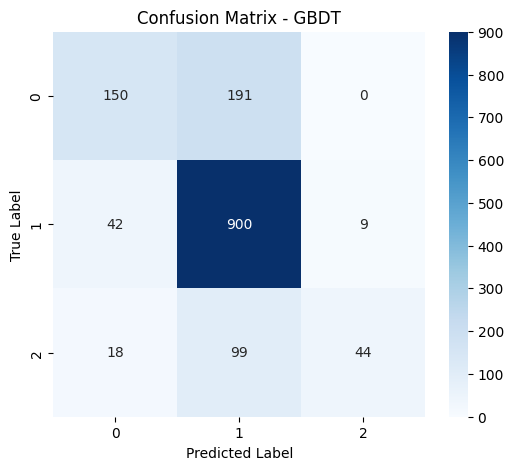

In [16]:
from sklearn.metrics import confusion_matrix
# Menampilkan confusion matrix
conf_matrix_gbdt = confusion_matrix(y_test, gbdt_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_gbdt, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - GBDT')
plt.show()

#### 2.Support Vector Classifier (SVC)

Tanggal  |  Durasi

6 Feb 2025  |  19s

In [17]:
# 2. Support Vector Classifier (SVC)
svc_model = SVC()
svc_model.fit(X_train_vectorized, y_train)
svc_pred = svc_model.predict(X_test_vectorized)
svc_accuracy = accuracy_score(y_test, svc_pred)
print(f'SVC Accuracy: {svc_accuracy}')
print(classification_report(y_test, svc_pred))

SVC Accuracy: 0.7894012388162422
              precision    recall  f1-score   support

           0       0.71      0.63      0.67       341
           1       0.81      0.92      0.86       951
           2       0.84      0.32      0.47       161

    accuracy                           0.79      1453
   macro avg       0.79      0.63      0.67      1453
weighted avg       0.79      0.79      0.77      1453



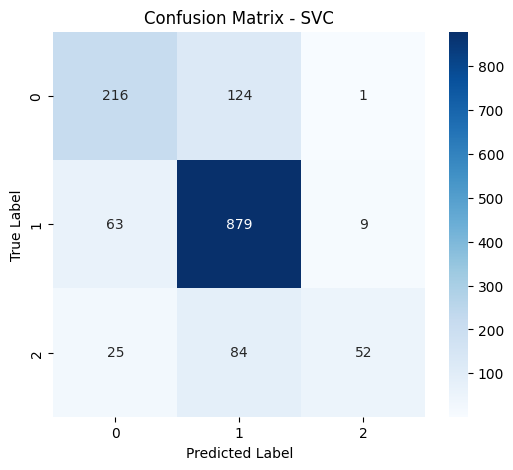

In [18]:
# Menampilkan confusion matrix
conf_matrix_svc = confusion_matrix(y_test, svc_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_svc, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - SVC')
plt.show()


#### 3.Extreme Gradient Boosting (XGBoost)

Tanggal  |  Durasi

6 Feb 2025  |  28s

In [19]:
# 3. Extreme Gradient Boosting (XGBoost)
xgb_model = XGBClassifier()
xgb_model.fit(X_train_vectorized, y_train)
xgb_pred = xgb_model.predict(X_test_vectorized)
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print(f'XGBoost Accuracy: {xgb_accuracy}')
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.7660013764624914
              precision    recall  f1-score   support

           0       0.64      0.65      0.65       341
           1       0.81      0.89      0.85       951
           2       0.67      0.30      0.42       161

    accuracy                           0.77      1453
   macro avg       0.71      0.61      0.64      1453
weighted avg       0.76      0.77      0.75      1453



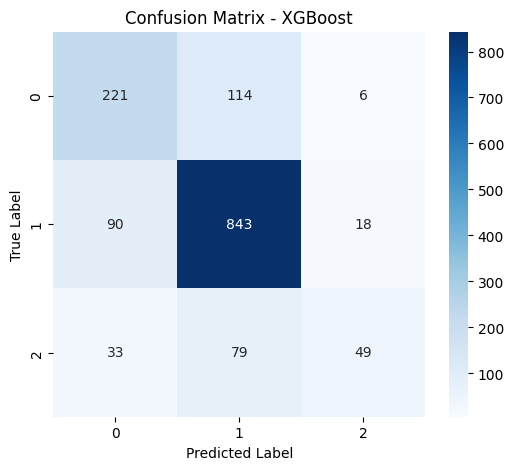

In [20]:
# Menampilkan confusion matrix
conf_matrix_xgb = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - XGBoost')
plt.show()

## Menggunakan Vader Lexion

### Pemisahan Fitur dan Label

In [21]:
# Fitur (teks tweet) dan Label untuk VADER
X_vader = db_merge['Stemmed_Text']  # Fitur (teks tweet)
y_vader = db_merge['VADER_Label_Numeric']  # Label sentimen dari VADER


### Pembagian Data untuk Pelatihan dan Pengujian

In [22]:
# Pembagian data menjadi training dan test set
X_train_vader, X_test_vader, y_train_vader, y_test_vader = train_test_split(X_vader, y_vader, test_size=0.2, random_state=42, stratify =y)


### Preprocessing Teks untuk Model

In [23]:
# Inisialisasi TfidfVectorizer
vectorizer_vader = TfidfVectorizer(stop_words=stop_words, max_features=5000)

# Jika data berupa list kata, gabungkan kata-katanya menjadi string
X_train_vader = X_train_vader.apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
X_test_vader = X_test_vader.apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

# Lanjutkan dengan proses vektorisasi
X_train_vectorized_vader = vectorizer_vader.fit_transform(X_train_vader)
X_test_vectorized_vader = vectorizer_vader.transform(X_test_vader)


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'banget', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


### Model Klasifikasi untuk VADER

#### 1.Gradient Boosted Decision Tree (GBDT)

Tanggal  |  Durasi

6 Feb 2025  |  18s

In [24]:
# 1. Gradient Boosted Decision Tree (GBDT) untuk VADER
gbdt_model_vader = GradientBoostingClassifier()
gbdt_model_vader.fit(X_train_vectorized_vader, y_train_vader)
gbdt_pred_vader = gbdt_model_vader.predict(X_test_vectorized_vader)
gbdt_accuracy_vader = accuracy_score(y_test_vader, gbdt_pred_vader)
print(f'GBDT Accuracy (VADER): {gbdt_accuracy_vader}')
print(classification_report(y_test_vader, gbdt_pred_vader))

GBDT Accuracy (VADER): 0.9559532002752925
              precision    recall  f1-score   support

           0       0.91      0.58      0.71        52
           1       0.95      1.00      0.98      1229
           2       0.98      0.76      0.85       172

    accuracy                           0.96      1453
   macro avg       0.95      0.78      0.85      1453
weighted avg       0.96      0.96      0.95      1453



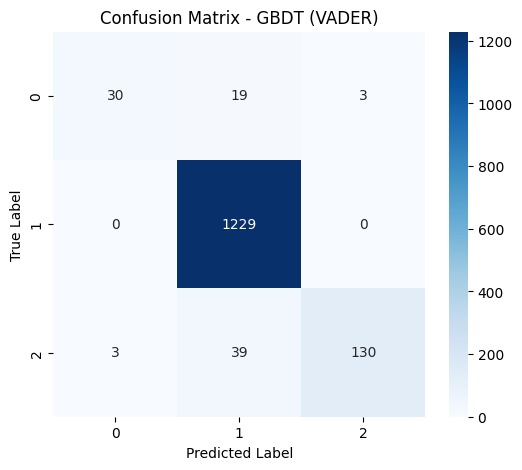

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Menampilkan confusion matrix
conf_matrix = confusion_matrix(y_test_vader, gbdt_pred_vader)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test_vader), yticklabels=np.unique(y_test_vader))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - GBDT (VADER)')
plt.show()

#### 2.Support Vector Classifier (SVC)

Tanggal  |  Durasi

6 Feb 2025  |  14s

In [26]:
# 2. Support Vector Classifier (SVC) untuk VADER
svc_model_vader = SVC()
svc_model_vader.fit(X_train_vectorized_vader, y_train_vader)
svc_pred_vader = svc_model_vader.predict(X_test_vectorized_vader)
svc_accuracy_vader = accuracy_score(y_test_vader, svc_pred_vader)
print(f'SVC Accuracy (VADER): {svc_accuracy_vader}')
print(classification_report(y_test_vader, svc_pred_vader))



SVC Accuracy (VADER): 0.9201651754989677
              precision    recall  f1-score   support

           0       1.00      0.17      0.30        52
           1       0.92      1.00      0.96      1229
           2       0.98      0.58      0.73       172

    accuracy                           0.92      1453
   macro avg       0.97      0.58      0.66      1453
weighted avg       0.93      0.92      0.90      1453



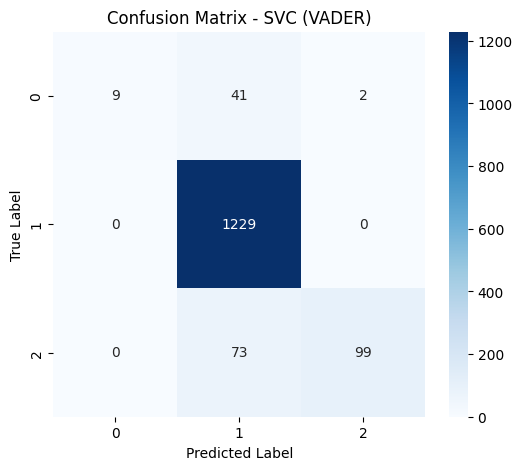

In [27]:
# Menampilkan confusion matrix
conf_matrix_svc = confusion_matrix(y_test_vader, svc_pred_vader)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_svc, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test_vader), yticklabels=np.unique(y_test_vader))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - SVC (VADER)')
plt.show()

#### 3.Extreme Gradient Boosting (XGBoost)

Tanggal  |  Durasi

6 Feb 2025  |  26s

In [28]:
# 3. Extreme Gradient Boosting (XGBoost) untuk VADER
xgb_model_vader = XGBClassifier()
xgb_model_vader.fit(X_train_vectorized_vader, y_train_vader)
xgb_pred_vader = xgb_model_vader.predict(X_test_vectorized_vader)
xgb_accuracy_vader = accuracy_score(y_test_vader, xgb_pred_vader)
print(f'XGBoost Accuracy (VADER): {xgb_accuracy_vader}')
print(classification_report(y_test_vader, xgb_pred_vader))


XGBoost Accuracy (VADER): 0.9525120440467997
              precision    recall  f1-score   support

           0       0.91      0.58      0.71        52
           1       0.95      1.00      0.98      1229
           2       0.98      0.73      0.83       172

    accuracy                           0.95      1453
   macro avg       0.95      0.77      0.84      1453
weighted avg       0.95      0.95      0.95      1453



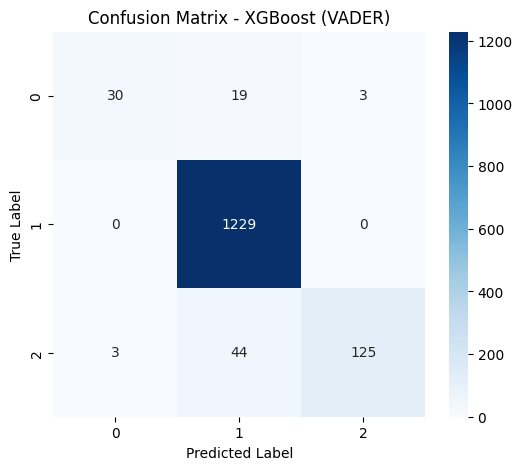

In [29]:
# Menampilkan confusion matrix
conf_matrix_xgb = confusion_matrix(y_test_vader, xgb_pred_vader)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test_vader), yticklabels=np.unique(y_test_vader))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - XGBoost (VADER)')
plt.show()

### Visualisasi Perbandingan Akurasi

In [30]:
# Akurasi model BERT
print(f'GBDT Accuracy (BERT): {gbdt_accuracy}')
print(f'SVC Accuracy (BERT): {svc_accuracy}')
print(f'XGBoost Accuracy (BERT): {xgb_accuracy}')

# Akurasi model VADER
print(f'GBDT Accuracy (VADER): {gbdt_accuracy_vader}')
print(f'SVC Accuracy (VADER): {svc_accuracy_vader}')
print(f'XGBoost Accuracy (VADER): {xgb_accuracy_vader}')


GBDT Accuracy (BERT): 0.7529249827942188
SVC Accuracy (BERT): 0.7894012388162422
XGBoost Accuracy (BERT): 0.7660013764624914
GBDT Accuracy (VADER): 0.9559532002752925
SVC Accuracy (VADER): 0.9201651754989677
XGBoost Accuracy (VADER): 0.9525120440467997


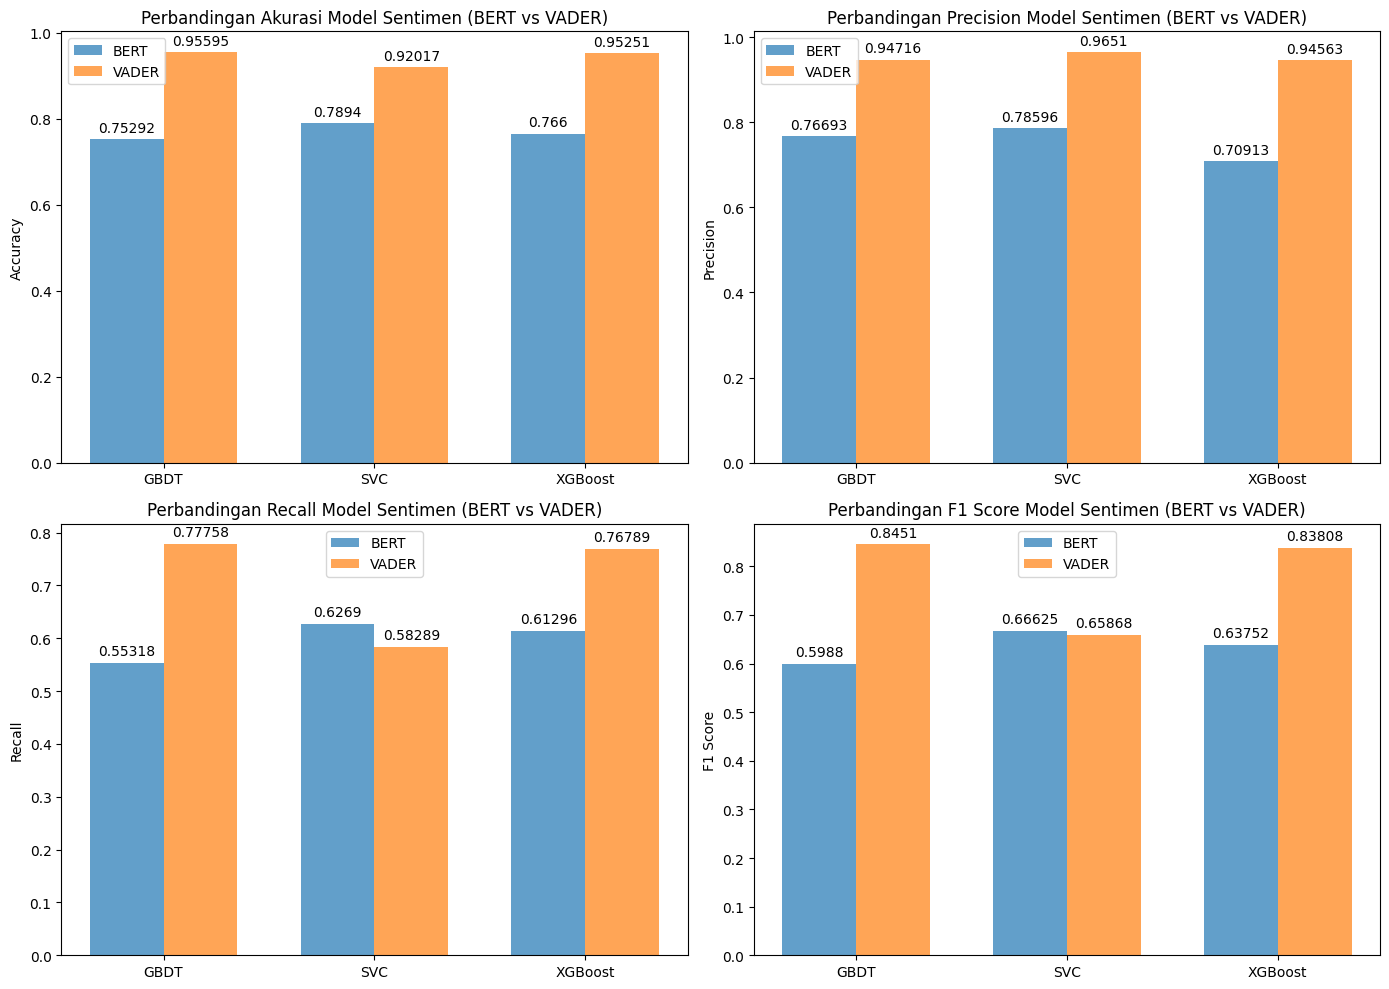

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Menyiapkan data untuk visualisasi
models = ['GBDT', 'SVC', 'XGBoost']
bert_accuracies = [gbdt_accuracy, svc_accuracy, xgb_accuracy]
vader_accuracies = [gbdt_accuracy_vader, svc_accuracy_vader, xgb_accuracy_vader]

# Menghitung precision, recall, dan F1 score
bert_precisions = [
    precision_score(y_test, gbdt_pred, average='macro'),
    precision_score(y_test, svc_pred, average='macro'),
    precision_score(y_test, xgb_pred, average='macro')
]

bert_recalls = [
    recall_score(y_test, gbdt_pred, average='macro'),
    recall_score(y_test, svc_pred, average='macro'),
    recall_score(y_test, xgb_pred, average='macro')
]

bert_f1_scores = [
    f1_score(y_test, gbdt_pred, average='macro'),
    f1_score(y_test, svc_pred, average='macro'),
    f1_score(y_test, xgb_pred, average='macro')
]

vader_precisions = [
    precision_score(y_test_vader, gbdt_pred_vader, average='macro'),
    precision_score(y_test_vader, svc_pred_vader, average='macro'),
    precision_score(y_test_vader, xgb_pred_vader, average='macro')
]

vader_recalls = [
    recall_score(y_test_vader, gbdt_pred_vader, average='macro'),
    recall_score(y_test_vader, svc_pred_vader, average='macro'),
    recall_score(y_test_vader, xgb_pred_vader, average='macro')
]

vader_f1_scores = [
    f1_score(y_test_vader, gbdt_pred_vader, average='macro'),
    f1_score(y_test_vader, svc_pred_vader, average='macro'),
    f1_score(y_test_vader, xgb_pred_vader, average='macro')
]

# Membuat plot perbandingan
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Memperbaiki jarak antar bar
bar_width = 0.35  # Lebar bar yang lebih kecil untuk memberikan jarak

# Plotting Accuracy
axes[0, 0].bar([i - bar_width/2 for i in range(len(models))], bert_accuracies, width=bar_width, label='BERT', alpha=0.7)
axes[0, 0].bar([i + bar_width/2 for i in range(len(models))], vader_accuracies, width=bar_width, label='VADER', alpha=0.7)
axes[0, 0].set_xticks(range(len(models)))
axes[0, 0].set_xticklabels(models)
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Perbandingan Akurasi Model Sentimen (BERT vs VADER)')
axes[0, 0].legend()

# Menambahkan nilai untuk Accuracy
for i, v in enumerate(bert_accuracies):
    axes[0, 0].text(i - bar_width/2, v + 0.01, str(round(v, 5)), ha='center', va='bottom', fontsize=10)
for i, v in enumerate(vader_accuracies):
    axes[0, 0].text(i + bar_width/2, v + 0.01, str(round(v, 5)), ha='center', va='bottom', fontsize=10)

# Plotting Precision
axes[0, 1].bar([i - bar_width/2 for i in range(len(models))], bert_precisions, width=bar_width, label='BERT', alpha=0.7)
axes[0, 1].bar([i + bar_width/2 for i in range(len(models))], vader_precisions, width=bar_width, label='VADER', alpha=0.7)
axes[0, 1].set_xticks(range(len(models)))
axes[0, 1].set_xticklabels(models)
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Perbandingan Precision Model Sentimen (BERT vs VADER)')
axes[0, 1].legend()

# Menambahkan nilai untuk Precision
for i, v in enumerate(bert_precisions):
    axes[0, 1].text(i - bar_width/2, v + 0.01, str(round(v, 5)), ha='center', va='bottom', fontsize=10)
for i, v in enumerate(vader_precisions):
    axes[0, 1].text(i + bar_width/2, v + 0.01, str(round(v, 5)), ha='center', va='bottom', fontsize=10)

# Plotting Recall
axes[1, 0].bar([i - bar_width/2 for i in range(len(models))], bert_recalls, width=bar_width, label='BERT', alpha=0.7)
axes[1, 0].bar([i + bar_width/2 for i in range(len(models))], vader_recalls, width=bar_width, label='VADER', alpha=0.7)
axes[1, 0].set_xticks(range(len(models)))
axes[1, 0].set_xticklabels(models)
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Perbandingan Recall Model Sentimen (BERT vs VADER)')
axes[1, 0].legend()

# Menambahkan nilai untuk Recall
for i, v in enumerate(bert_recalls):
    axes[1, 0].text(i - bar_width/2, v + 0.01, str(round(v, 5)), ha='center', va='bottom', fontsize=10)
for i, v in enumerate(vader_recalls):
    axes[1, 0].text(i + bar_width/2, v + 0.01, str(round(v, 5)), ha='center', va='bottom', fontsize=10)

# Plotting F1 Score
axes[1, 1].bar([i - bar_width/2 for i in range(len(models))], bert_f1_scores, width=bar_width, label='BERT', alpha=0.7)
axes[1, 1].bar([i + bar_width/2 for i in range(len(models))], vader_f1_scores, width=bar_width, label='VADER', alpha=0.7)
axes[1, 1].set_xticks(range(len(models)))
axes[1, 1].set_xticklabels(models)
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Perbandingan F1 Score Model Sentimen (BERT vs VADER)')
axes[1, 1].legend()

# Menambahkan nilai untuk F1 Score
for i, v in enumerate(bert_f1_scores):
    axes[1, 1].text(i - bar_width/2, v + 0.01, str(round(v, 5)), ha='center', va='bottom', fontsize=10)
for i, v in enumerate(vader_f1_scores):
    axes[1, 1].text(i + bar_width/2, v + 0.01, str(round(v, 5)), ha='center', va='bottom', fontsize=10)

# Menampilkan plot
plt.tight_layout()
plt.show()


### Interpretasi

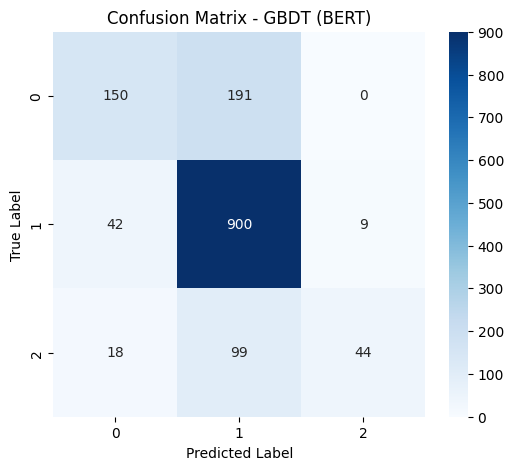

In [32]:
# Menampilkan confusion matrix
conf_matrix_gbdt = confusion_matrix(y_test, gbdt_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_gbdt, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - GBDT (BERT)')
plt.show()

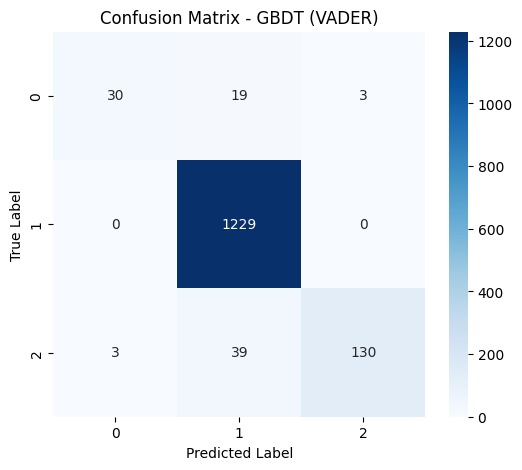

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Menampilkan confusion matrix
conf_matrix = confusion_matrix(y_test_vader, gbdt_pred_vader)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test_vader), yticklabels=np.unique(y_test_vader))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - GBDT (VADER)')
plt.show()